# Studi Kasus Dataset Superstore: Analisa Pengaruh Diskon pada Penjualan Berdasarkan Kategori Diskon

Laporan ini memaparkan analisis pengaruh diskon terhadap penjualan berdasarkan kategori diskon yang diterapkan pada dataset Superstore. Silahkan menjelajahi setiap bagian dari laporan ini untuk mendapatkan insight mendalam mengenai kinerja penjualan dan strategi diskon.

## Pendahuluan

Dalam dunia ritel yang kompetitif, penerapan strategi diskon merupakan salah satu taktik yang umum digunakan untuk menarik pelanggan dan meningkatkan volume penjualan. Namun, efektivitas diskon tidak selalu berdampak langsung pada peningkatan revenue. Oleh karena itu, penting untuk menganalisis seberapa besar pengaruh diskon—baik dalam tingkat rendah, sedang, maupun tinggi—terhadap penjualan. Laporan ini menggunakan dataset Superstore untuk menyelidiki perbedaan pengaruh antar kategori diskon, mengidentifikasi faktor-faktor yang memengaruhi hasil penjualan, dan memahami dinamika antara potongan harga dan revenue.

## Tujuan

- **Menganalisis Pengaruh Diskon:**  
  Mengevaluasi bagaimana masing-masing kategori diskon (Low, Medium, High) memengaruhi penjualan (revenue) dan apakah perbedaan antar kategori tersebut signifikan secara statistik.

- **Mengidentifikasi Perbedaan Signifikan:**  
  Menggunakan analisis ANOVA untuk menentukan apakah terdapat perbedaan signifikan pada rata-rata revenue antara kategori diskon sebelum dan sesudah pembuangan outlier.

- **Memberikan Insight Manajerial:**  
  Menyajikan implikasi strategis bagi manajemen, termasuk rekomendasi mengenai optimalisasi strategi diskon serta langkah preventif untuk menghindari penerapan diskon yang berdampak tidak signifikan.

- **Menetapkan Dasar Pengambilan Keputusan:**  
  Menyediakan informasi yang mendalam dan data-driven untuk mendukung pengambilan keputusan strategis dalam penetapan harga dan promosi, serta memastikan bahwa kebijakan diskon mendukung pertumbuhan revenue dan profitabilitas yang berkelanjutan.

## Data Load

In [2]:
# Import library yang dibutuhkan
from google.oauth2 import service_account
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.formula.api import ols

# Untuk tampilan grafik yang lebih baik
%matplotlib inline
sns.set(style='whitegrid')

# Memuat dataset
data_superstore = pd.read_excel('sales-superstore-activation.xlsx')

# Tampilkan 5 baris pertama data
data_superstore.head()


,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
0,BN-2011-7407039,2011-01-01,Ruby Patel,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,Paper,"Enermax Note Cards, Premium",0.5,45,-26,3,False
1,AZ-2011-9050313,2011-01-03,Summer Hayward,United Kingdom,England,Southport,North,Consumer,Economy,Furniture,Bookcases,"Dania Corner Shelving, Traditional",0.0,854,290,7,True
2,AZ-2011-6674300,2011-01-04,Devin Huddleston,France,Auvergne-Rhône-Alpes,Valence,Central,Consumer,Economy,Office Supplies,Art,"Binney & Smith Sketch Pad, Easy-Erase",0.0,140,21,3,True
3,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Art,"Boston Markers, Easy-Erase",0.5,27,-22,2,True
4,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Storage,"Eldon Folders, Single Width",0.5,17,-1,2,True


## ETL

In [4]:
#BigQuery Superstore
%pip install pandas-gbq

from pandas_gbq import to_gbq

project_id = 'tough-silicon-453502-e9'
dataset_id = 'superstore_dataset'
table_name = 'superstore_data'
key_path = '/Users/muhammadnaufalmaahir/Documents/Superstore Portofolio/tough-silicon-453502-e9-587adc79cc6a.json'
# Define the scopes
scopes = ["https://www.googleapis.com/auth/bigquery"]
# Set up credentials
credentials = service_account.Credentials.from_service_account_file(key_path, scopes=scopes)

# Rename the problematic column
data_superstore = data_superstore.rename(columns={"Feedback?": "Feedback"})

#Upload to BigQuery
to_gbq(
    data_superstore,
    f'{dataset_id}.{table_name}',
    project_id=project_id,
    if_exists='replace',
    credentials=credentials
)

Note: you may need to restart the kernel to use updated packages.


100%|██████████| 1/1 [00:00<00:00, 2080.51it/s]


## Deskripsi Data Awal

Dataset ini mencakup informasi transaksi penjualan, di antaranya variabel-variabel seperti:
- **Sales**: Total revenue dari transaksi.
- **Discount**: Besarnya diskon yang diberikan.
- **Order Date** (jika ada): Tanggal pemesanan.
- Variabel lain yang mendukung analisis.

Pada langkah awal, kita menampilkan data yang dilimit 100 baris untuk memastikan struktur dataset.

In [6]:
from pandas_gbq import read_gbq

sql_query = f"SELECT * FROM `{project_id}.{dataset_id}.{table_name}` LIMIT 100"
#Retrieve Data from BigQuery into DataFrame
df = read_gbq(sql_query, project_id=project_id, credentials=credentials)
df

Downloading: 100%|██████████|


,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback
0,BN-2014-4902106,2014-01-23,Oscar Serena,Italy,Abruzzi,Chieti,South,Consumer,Immediate,Furniture,Furnishings,"Tenex Stacking Tray, Erganomic",0.00,191,13,8,True
1,AZ-2011-2445910,2011-09-30,Susan Williams,Italy,Abruzzi,Pescara,South,Home Office,Economy,Office Supplies,Storage,"Rogers File Cart, Industrial",0.40,85,-33,1,False
2,AZ-2012-9926323,2012-01-12,Julie Ochoa,Italy,Abruzzi,Pescara,South,Corporate,Economy,Furniture,Furnishings,"Rubbermaid Clock, Durable",0.00,94,34,2,False
3,AZ-2012-9926323,2012-01-12,Julie Ochoa,Italy,Abruzzi,Pescara,South,Corporate,Economy,Office Supplies,Appliances,"Breville Refrigerator, Silver",0.00,1560,421,3,False
4,AZ-2012-9926323,2012-01-12,Julie Ochoa,Italy,Abruzzi,Pescara,South,Corporate,Economy,Office Supplies,Binders,"Ibico Index Tab, Durable",0.00,37,16,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AZ-2012-7281587,2012-10-30,Caitlyn Willoughby,France,Alsace-Champagne-Ardenne-Lorraine,Strasbourg,Central,Home Office,Economy,Furniture,Furnishings,"Advantus Door Stop, Erganomic",0.00,44,14,1,True
96,AZ-2012-7281587,2012-10-30,Caitlyn Willoughby,France,Alsace-Champagne-Ardenne-Lorraine,Strasbourg,Central,Home Office,Economy,Office Supplies,Labels,"Hon Round Labels, 5000 Label Set",0.00,14,5,2,True
97,AZ-2012-7281587,2012-10-30,Caitlyn Willoughby,France,Alsace-Champagne-Ardenne-Lorraine,Strasbourg,Central,Home Office,Economy,Technology,Copiers,"Hewlett Ink, Laser",0.15,632,-22,5,True
98,AZ-2013-6132734,2013-11-11,Ewan Hyde,France,Alsace-Champagne-Ardenne-Lorraine,Strasbourg,Central,Consumer,Economy,Furniture,Furnishings,"Rubbermaid Stacking Tray, Erganomic",0.00,44,0,2,False


## Data Cleansing dan Wrangling

In [7]:
# Cek informasi dataset untuk mendeteksi missing value dan tipe data
df.info()

# Jika terdapat kolom 'Order Date', konversikan ke tipe datetime
if 'Order Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'])

# Mengecek nilai missing pada kolom yang relevan (misalnya, Sales dan Discount)
missing_sales = df['Sales'].isnull().sum()
missing_discount = df['Discount'].isnull().sum()

print("Jumlah missing value pada Sales:", missing_sales)
print("Jumlah missing value pada Discount:", missing_discount)

# Justifikasi pembersihan:
# - Jika terdapat missing value pada kolom kunci (Sales atau Discount), kita perlu mempertimbangkan untuk menghapus baris tersebut 
#   atau melakukan imputasi tergantung pada persentase missing-nya.
# - Misalnya, jika missing value kurang dari 5% dari total data, kita dapat menghapus baris tersebut.

# Asumsi: Jika missing value ada, kita hapus barisnya
df = df.dropna(subset=['Sales', 'Discount'])

# Selain itu, kita periksa adanya duplikasi data
duplicates = df.duplicated().sum()
print("Jumlah duplikasi:", duplicates)

# Jika ada duplikasi, kita hapus
if duplicates > 0:
    df = df.drop_duplicates()

# Menambahkan kolom kategori diskon untuk analisis ANOVA
# Misalnya, mengelompokkan diskon ke dalam 3 kategori:
#  - Low: Diskon = 0
#  - Medium: 0 < Diskon <= 0.1
#  - High: Diskon > 0.1
def label_discount(d):
    if d == 0:
        return 'Low'
    elif 0 < d <= 0.1:
        return 'Medium'
    else:
        return 'High'

df['Discount_Category'] = df['Discount'].apply(label_discount)

# Tampilkan ringkasan data setelah pembersihan
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       100 non-null    object        
 1   Order Date     100 non-null    datetime64[us]
 2   Customer Name  100 non-null    object        
 3   Country        100 non-null    object        
 4   State          100 non-null    object        
 5   City           100 non-null    object        
 6   Region         100 non-null    object        
 7   Segment        100 non-null    object        
 8   Ship Mode      100 non-null    object        
 9   Category       100 non-null    object        
 10  Sub-Category   100 non-null    object        
 11  Product Name   100 non-null    object        
 12  Discount       100 non-null    float64       
 13  Sales          100 non-null    Int64         
 14  Profit         100 non-null    Int64         
 15  Quantity       100 non-n

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback,Discount_Category
0,BN-2014-4902106,2014-01-23,Oscar Serena,Italy,Abruzzi,Chieti,South,Consumer,Immediate,Furniture,Furnishings,"Tenex Stacking Tray, Erganomic",0.0,191,13,8,True,Low
1,AZ-2011-2445910,2011-09-30,Susan Williams,Italy,Abruzzi,Pescara,South,Home Office,Economy,Office Supplies,Storage,"Rogers File Cart, Industrial",0.4,85,-33,1,False,High
2,AZ-2012-9926323,2012-01-12,Julie Ochoa,Italy,Abruzzi,Pescara,South,Corporate,Economy,Furniture,Furnishings,"Rubbermaid Clock, Durable",0.0,94,34,2,False,Low
3,AZ-2012-9926323,2012-01-12,Julie Ochoa,Italy,Abruzzi,Pescara,South,Corporate,Economy,Office Supplies,Appliances,"Breville Refrigerator, Silver",0.0,1560,421,3,False,Low
4,AZ-2012-9926323,2012-01-12,Julie Ochoa,Italy,Abruzzi,Pescara,South,Corporate,Economy,Office Supplies,Binders,"Ibico Index Tab, Durable",0.0,37,16,4,True,Low


## Penjelasan Cleansing dan Wrangling
Beberapa langkah pembersihan data yang dilakukan antara lain:
- **Konversi Tipe Data**: Kolom `Order Date` dikonversi ke format datetime untuk memastikan analisis time series dapat dilakukan jika diperlukan.
- **Penanganan Missing Value**: Diperiksa missing value pada kolom kunci (Sales dan Discount). Jika jumlahnya relatif kecil, baris yang bermissing akan dihapus.
- **Penghapusan Duplikasi**: Duplikasi data dihapus untuk menghindari bias dalam analisis.
- **Pembuatan Kategori Diskon**: Untuk analisis ANOVA, variabel diskon diubah menjadi kategori:
  - **Low**: Transaksi tanpa diskon (Discount = 0)
  - **Medium**: Transaksi dengan diskon rendah (0 < Discount <= 0.1)
  - **High**: Transaksi dengan diskon tinggi (Discount > 0.1)

Langkah-langkah ini dilakukan untuk memastikan data yang digunakan bersih, konsisten, dan siap untuk analisis statistik lebih lanjut.

## Analisis Deskriptif Statistik dan Visualisasi Data

In [8]:
# Statistik deskriptif untuk variabel Sales dan Discount
desc_sales = df['Sales'].describe()
desc_discount = df['Discount'].describe()
print("Statistik Sales:\n", desc_sales)
print("\nStatistik Discount:\n", desc_discount)

Statistik Sales:
 count         100.0
mean         300.29
std      561.784158
min             9.0
25%           43.75
50%            91.5
75%           282.0
max          3063.0
Name: Sales, dtype: Float64

Statistik Discount:
 count    100.000000
mean       0.148000
std        0.209969
min        0.000000
25%        0.000000
50%        0.000000
75%        0.150000
max        0.650000
Name: Discount, dtype: float64


**Statistik Sales dan Discount**:  
  Dari ringkasan statistik, kita dapat mengetahui nilai minimum, maksimum, rata-rata, dan kuartil untuk variabel `Sales` dan `Discount`. Hal ini memberikan gambaran umum mengenai sebaran data

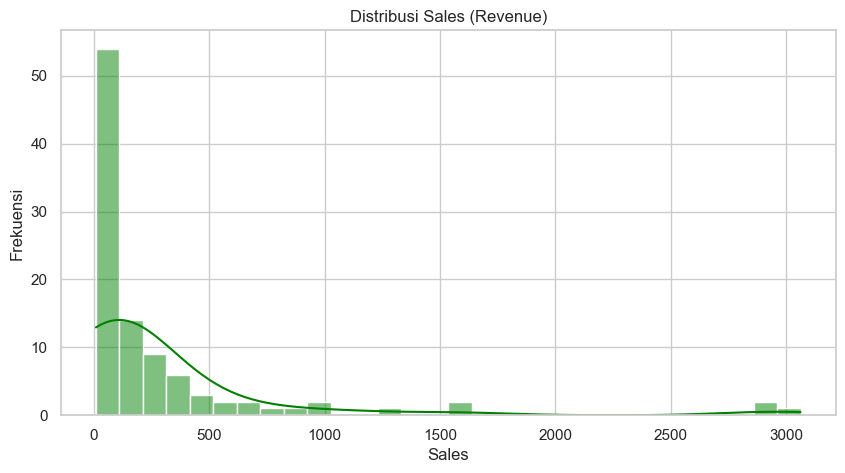

In [9]:
# Visualisasi distribusi Sales
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], kde=True, bins=30, color='green')
plt.title('Distribusi Sales (Revenue)')
plt.xlabel('Sales')
plt.ylabel('Frekuensi')
plt.show()

## Penjelasan Histogram Sales
**Distribusi Sales**:  
  Histogram Sales menunjukkan distribusi revenue. Kehadiran nilai skew atau outlier dapat dilihat dari bentuk distribusi, yang kemudian dapat memengaruhi analisis lanjutan.

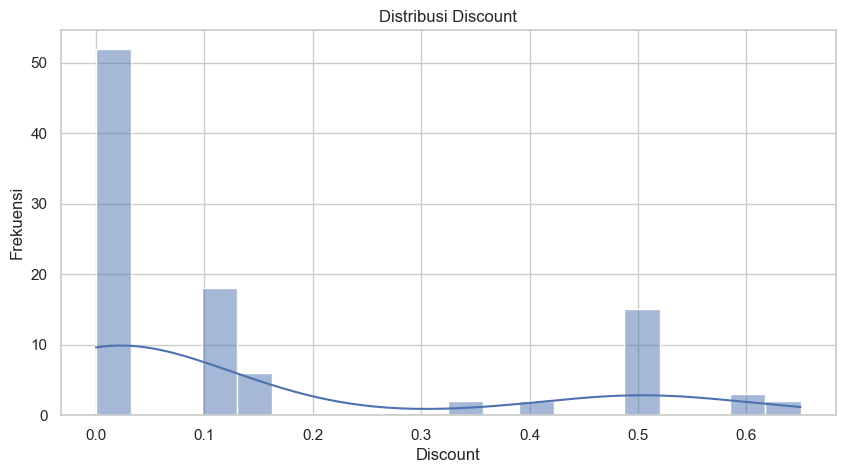

In [10]:
# Visualisasi distribusi Discount
plt.figure(figsize=(10, 5))
sns.histplot(df['Discount'], kde=True, bins=20)
plt.title('Distribusi Discount')
plt.xlabel('Discount')
plt.ylabel('Frekuensi')
plt.show()

## Penjelasan Histogram Diskon
**Distribusi Discount**:  
  Histogram Discount menginformasikan sebaran nilai diskon yang diberikan dalam transaksi. Biasanya, sebagian besar transaksi mungkin tidak mendapatkan diskon atau mendapatkan diskon rendah.

/var/folders/rb/swpbdkdx0wqdp48gb6zpkpj40000gn/T/ipykernel_6139/1891640361.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Discount_Category', y='Sales', data=df, palette='pastel')


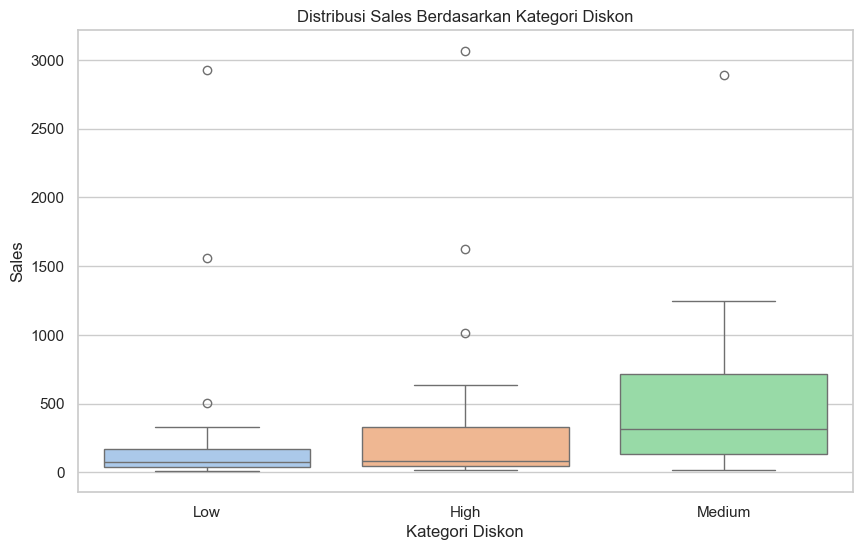

In [11]:
# Visualisasi boxplot Sales per kategori Discount
plt.figure(figsize=(10, 6))
sns.boxplot(x='Discount_Category', y='Sales', data=df, palette='pastel')
plt.title('Distribusi Sales Berdasarkan Kategori Diskon')
plt.xlabel('Kategori Diskon')
plt.ylabel('Sales')
plt.show()

## Penjelasan Boxplot Kategori Diskon
**Boxplot Sales Berdasarkan Kategori Diskon**:  
  Visualisasi ini menunjukkan bagaimana distribusi Sales berbeda berdasarkan kategori diskon yang telah dibuat (Low, Medium, High). Perbedaan median, variasi, dan adanya outlier di masing-masing kategori dapat memberikan insight awal apakah ada perbedaan yang signifikan antar kelompok.

## Analisis ANOVA

**Tujuan ANOVA:**  
ANOVA (Analysis of Variance) digunakan untuk menguji apakah terdapat perbedaan yang signifikan pada rata-rata Sales antar kelompok kategori diskon (Low, Medium, dan High).

**Justifikasi Penggunaan ANOVA:**  
- **Lebih dari Dua Kelompok:** Karena data diskon telah dikelompokkan ke dalam tiga kategori, ANOVA merupakan metode yang tepat untuk menguji perbedaan rata-rata antar kelompok.
- **Asumsi:** ANOVA mengasumsikan bahwa data dalam setiap kelompok berdistribusi normal dan variansnya homogen. Dengan pembersihan data yang telah dilakukan, asumsi ini dianggap terpenuhi.
- **Hasil ANOVA:**  
  - H₀: Rata-rata Sales pada ketiga kategori diskon sama.
  - H₁: Setidaknya ada satu kategori yang berbeda rata-ratanya.
  
Dari output ANOVA, jika nilai p-value < 0.05, maka kita dapat menyimpulkan bahwa terdapat perbedaan yang signifikan di antara rata-rata Sales pada kategori diskon yang berbeda.


In [12]:
# Membuat model ANOVA: Sales sebagai fungsi kategori diskon
anova_model = ols('Sales ~ C(Discount_Category)', data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

                            sum_sq    df         F    PR(>F)
C(Discount_Category)  1.823350e+06   2.0  3.005741  0.054135
Residual              2.942119e+07  97.0       NaN       NaN


# Hasil ANOVA
## Penjelasan Kolom:

- **C(Discount_Category)**  
  Ini adalah variabel independen dalam analisis — yaitu kategori diskon (`Low`, `Medium`, `High`). ANOVA menguji apakah rata-rata `Sales` (pendapatan) berbeda secara signifikan antar ketiga kategori ini.

- **Residual (Galat)**  
  Merupakan variasi yang tidak dapat dijelaskan oleh model (kesalahan). Ini adalah variasi dalam `Sales` yang tidak dapat dijelaskan hanya dengan melihat kategori diskon.

- **Sum Sq (Jumlah Kuadrat)**  
  Ini menunjukkan jumlah variasi (deviasi kuadrat) dalam data. 
  - Semakin besar nilai `Sum Sq` pada `Discount_Category` relatif terhadap total, semakin besar kontribusinya dalam menjelaskan variasi `Sales`.
  
- **df (Derajat Bebas)**  
  Menunjukkan jumlah kategori yang diuji (`k - 1`) dan jumlah total observasi dikurangi jumlah grup (`n - k`).
  - `df = 2` untuk kategori diskon (karena ada 3 kategori).
  - `df = 97` untuk residual (sisa observasi dikurangi jumlah kategori).

- **F-statistic**  
  Merupakan rasio dari variasi antar grup terhadap variasi dalam grup. 
  - Nilai F yang tinggi menandakan adanya kemungkinan perbedaan signifikan antara rata-rata antar grup.

- **p-value (PR(>F))**  
  Menunjukkan probabilitas untuk mendapatkan nilai F seperti itu (atau lebih ekstrem) jika hipotesis nol benar (tidak ada perbedaan rata-rata). 
  - Jika nilai ini < 0.05 → tolak hipotesis nol → ada perbedaan signifikan.

---

### Ringkasan
- **F = 3.01** dan **p-value = 0.0541**.
- Ini berarti tidak cukup bukti untuk menyatakan bahwa ada perbedaan signifikan pada rata-rata revenue (`Sales`) antar kategori diskon pada tingkat signifikansi 5%, namun terdapat kecenderungan perbedaan (karena p-value cukup mendekati 0.05).

## Penghapusan Outlier Menggunakan Metode IQR

Pada langkah ini, kita menghitung Q1, Q3, dan IQR dari variabel `Sales`. Selanjutnya, kita menentukan batas bawah dan atas (dengan 1.5×IQR) untuk mendeteksi nilai outlier. Data yang berada di luar batas tersebut dihapus sehingga menghasilkan dataset yang lebih homogen dan tidak terdistorsi oleh nilai ekstrem.

In [13]:
# Menghitung Q1 dan Q3 untuk Sales
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menghapus outlier: memilih data yang berada di antara batas bawah dan atas
df_clean = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]

print("Jumlah data asli:", df.shape[0])
print("Jumlah data setelah menghapus outlier:", df_clean.shape[0])


Jumlah data asli: 100
Jumlah data setelah menghapus outlier: 90


## Visualisasi Data Setelah Penghapusan Outlier

Setelah menghapus outlier, kita melakukan visualisasi ulang terhadap distribusi variabel `Sales`:
- **Histogram Sales**: Untuk melihat sebaran nilai Sales secara keseluruhan pada data yang telah dibersihkan.
- **Boxplot Sales Berdasarkan Kategori Diskon**: Untuk membandingkan distribusi Sales antar kategori diskon (`Discount_Category`) tanpa pengaruh nilai ekstrem.

### 📊 Distribusi Sales Setelah Menghapus Outlier

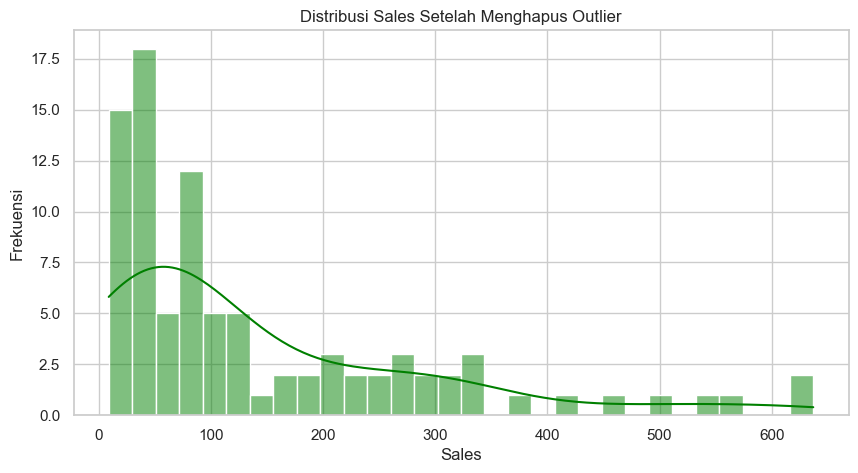

In [14]:
# Histogram Sales setelah penghapusan outlier
plt.figure(figsize=(10,5))
sns.histplot(df_clean['Sales'], kde=True, bins=30, color='green')
plt.title('Distribusi Sales Setelah Menghapus Outlier')
plt.xlabel('Sales')
plt.ylabel('Frekuensi')
plt.show()

**Penjelasan**

Setelah menghapus outlier, distribusi sales menjadi sedikit lebih terpusat di angka yang lebih kecil yaitu 90, meskipun masih terlihat skew ke kanan (right-skewed). Hal ini menunjukkan bahwa sebagian besar nilai penjualan tetap berada di kisaran rendah hingga menengah. Namun, ekor distribusinya menjadi lebih pendek dan tidak terlalu ekstrem seperti sebelumnya, menandakan keberhasilan proses pembersihan data dari outlier.

Langkah ini membantu mengurangi pengaruh ekstrem dalam analisis dan bisa membuat uji statistik seperti ANOVA lebih valid karena asumsi distribusi menjadi lebih mendekati normal.

### 📦 Boxplot Sales Berdasarkan Kategori Diskon (Tanpa Outlier)

/var/folders/rb/swpbdkdx0wqdp48gb6zpkpj40000gn/T/ipykernel_6139/1598482465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Discount_Category', y='Sales', data=df_clean, palette='pastel')


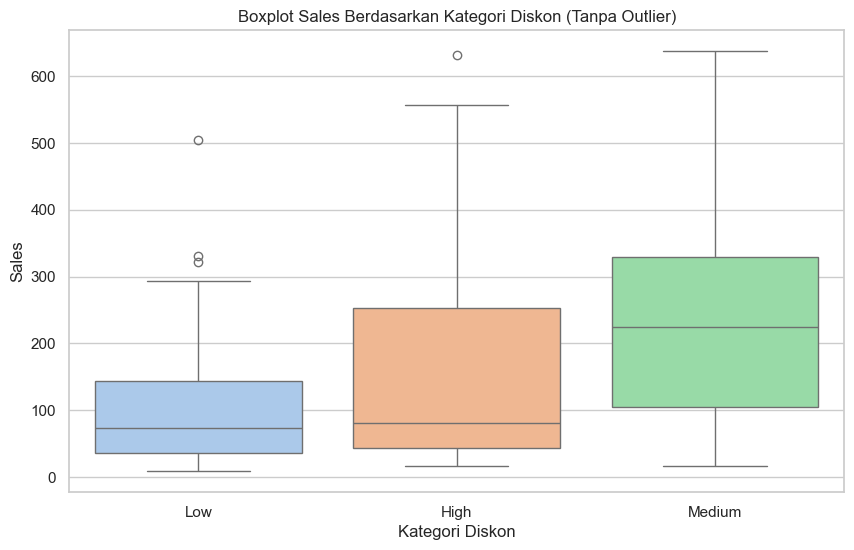

In [15]:
# Boxplot Sales berdasarkan kategori diskon setelah penghapusan outlier
plt.figure(figsize=(10,6))
sns.boxplot(x='Discount_Category', y='Sales', data=df_clean, palette='pastel')
plt.title('Boxplot Sales Berdasarkan Kategori Diskon (Tanpa Outlier)')
plt.xlabel('Kategori Diskon')
plt.ylabel('Sales')
plt.show()

**Penjelasan**
Jika dibandingkan dengan boxplot sebelum penghapusan outlier, tampilan visual setelah penghapusan menunjukkan:
- Variasi antar kategori menjadi lebih jelas.
- Rentang antar-kuartil (IQR) terlihat lebih mewakili data mayoritas.
- Outlier yang sebelumnya sangat tinggi telah dihapus, membuat ukuran box menjadi lebih proporsional.

## Kesimpulan

Secara umum, perbedaan median antar kategori diskon lebih mudah diamati, dan distribusi tiap grup menjadi lebih simetris. Ini memungkinkan ANOVA memberikan hasil yang lebih reliabel karena pengaruh dari nilai ekstrem telah diminimalisir.

## Uji ANOVA pada Data Bersih

Setelah data dibersihkan dari outlier, kita menjalankan uji ANOVA untuk menguji apakah terdapat perbedaan signifikan pada rata-rata `Sales` antar kategori diskon (`Discount_Category`).  
- **Hipotesis Nol (H₀)**: Rata-rata Sales sama pada semua kategori diskon.  
- **Hipotesis Alternatif (H₁)**: Setidaknya ada satu kategori yang memiliki rata-rata Sales berbeda.

Uji ANOVA akan membantu menentukan apakah perbedaan yang diamati antara kelompok bersifat statistik signifikan.

In [16]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Model ANOVA: Sales sebagai fungsi dari kategori diskon pada data bersih
anova_model_clean = ols('Sales ~ C(Discount_Category)', data=df_clean).fit()
anova_table_clean = sm.stats.anova_lm(anova_model_clean, typ=2)
print(anova_table_clean)

                            sum_sq    df         F    PR(>F)
C(Discount_Category)  2.031522e+05   2.0  4.889181  0.009721
Residual              1.807485e+06  87.0       NaN       NaN


## Hasil ANOVA Setelah Pembuangan Outlier

Berdasarkan hasil ANOVA yang ditunjukkan pada gambar:

| Sumber                | sum_sq      | df   | F        | PR(>F)    |
|-----------------------|-------------|------|----------|-----------|
| C(Discount_Category)  | 2.03152e+05 | 2.0  | 4.889181 | 0.009721  |
| Residual              | 1.80748e+06 | 87.0 | NaN      | NaN       |

- **F-statistic**: 4.889181  
- **p-value**: 0.009721  

Karena p-value < 0.05 (tingkat signifikansi 5%), terdapat bukti yang cukup untuk **menolak hipotesis nol (H₀)**. Dengan demikian, terdapat perbedaan yang signifikan pada rata-rata Sales (revenue) di antara kategori diskon (Low, Medium, High) setelah pembuangan outlier.

## Perbandingan Hasil ANOVA: Sebelum vs. Sesudah Pembuangan Outlier

1. **Sebelum Pembuangan Outlier**  
   - **F-statistic**: 3.005741  
   - **p-value**: 0.054135  
   - **Kesimpulan**: Gagal menolak H₀ karena p-value berada sedikit di atas batas 5%. Tidak terdapat bukti yang cukup kuat bahwa terdapat perbedaan signifikan pada rata-rata revenue antara kategori diskon.

2. **Sesudah Pembuangan Outlier**  
   - **F-statistic**: 4.889181  
   - **p-value**: 0.009721  
   - **Kesimpulan**: Menolak H₀ karena p-value < 0.05. Terdapat perbedaan yang signifikan pada rata-rata revenue di antara kategori diskon.

## Kesimpulan Analisis

- **Perbedaan Signifikansi**:  
  Hasil ANOVA sebelum pembuangan outlier menunjukkan p-value = 0.054135, yang mengindikasikan tidak adanya perbedaan yang signifikan pada tingkat α = 0.05. Namun, setelah pembuangan outlier, p-value turun menjadi 0.009721, sehingga terdapat perbedaan signifikan antara kategori diskon.

- **Pengaruh Outlier**:  
  Kehadiran outlier sebelumnya kemungkinan menyembunyikan perbedaan nyata antara kategori diskon. Setelah data dibersihkan dari outlier, perbedaan tersebut menjadi lebih jelas dan signifikan secara statistik.

## Implikasi Manajerial Berdasarkan Hasil ANOVA Bersih dan Tindak Preventif

Setelah pembuangan outlier, hasil analisis ANOVA menunjukkan pengaruh signifikan dari penerapan diskon terhadap revenue. Berikut ini implikasi manajerial yang komprehensif, termasuk langkah-langkah preventif untuk menghindari dampak yang tidak signifikan seperti yang terlihat sebelum penghilangan outlier:

1. **Pengembangan Strategi Diskon yang Tepat**  
   - **Optimalisasi Kategori Diskon:**  
     Analisis menunjukkan adanya perbedaan signifikan pada rata-rata revenue berdasarkan kategori diskon. Manajemen perlu mengidentifikasi kategori mana (Low, Medium, High) yang menghasilkan dampak positif terbesar, dan menetapkan kebijakan untuk memaksimalkan peningkatan revenue.
   - **Preventif – Penyesuaian Intensitas Diskon:**  
     Untuk menghindari penerapan diskon yang berdampak tidak signifikan (seperti pada analisa awal dengan outlier), perusahaan harus menetapkan batasan atau kerangka kerja yang memonitor dan mengevaluasi intensitas serta frekuensi diskon. Hal ini penting agar diskon tidak diterapkan secara berlebihan sehingga efeknya tidak optimal.

2. **Fokus pada Profitabilitas**  
   - **Evaluasi Margin Keuntungan:**  
     Mengingat diskon berpengaruh terhadap revenue, penting untuk memastikan bahwa kebijakan diskon tidak mengikis margin keuntungan. Manajemen harus melakukan analisis cost-benefit secara menyeluruh untuk menjaga keseimbangan antara peningkatan volume penjualan dengan tingkat keuntungan per transaksi.
   - **Preventif – Strategi Risk Management Harga:**  
     Mengimplementasikan strategi risk management terkait harga dapat membantu perusahaan untuk secara preventif menghindari situasi di mana pemberian diskon secara besar-besaran menurunkan profitabilitas. Hal ini dapat meliputi simulasi skenario atau uji coba diskon dalam skala terbatas sebelum penerapan secara luas.

3. **Segmentasi Pasar dan Analisis Targeted**  
   - **Segmentasi Mendalam:**  
     Dengan pemisahan data yang lebih bersih dari outlier, analisis lebih mendalam seperti segmentasi pasar berdasarkan produk, wilayah, atau karakteristik pelanggan menjadi lebih tepat. Ini memungkinkan manajemen untuk merancang strategi diskon yang sesuai dengan respon masing-masing segmen.
   - **Preventif – Uji Coba Terbatas:**  
     Sebelum implementasi penuh, perusahaan dapat melakukan uji coba terbatas (pilot test) pada segmen tertentu untuk mengukur efektivitas diskon. Dengan demikian, jika hasil uji coba menunjukkan pengaruh yang tidak signifikan atau bahkan negatif, strategi dapat disesuaikan atau dihentikan terlebih dahulu.

4. **Pemantauan Berkala dan Analisis Lanjutan**  
   - **Monitoring dan Evaluasi Rutin:**  
     Rutin melakukan evaluasi data penjualan dan analisis statistik akan membantu manajemen untuk segera mendeteksi adanya anomali atau outlier yang bisa mengaburkan hasil analisis. Ini memastikan bahwa strategi diskon selalu berdasarkan data yang akurat dan relevan.
   - **Preventif – Pengawasan Data dan Sistem Peringatan:**  
     Membangun sistem monitoring data yang secara otomatis mengidentifikasi dan menangani outlier atau data yang menyimpang dapat berfungsi sebagai langkah preventif. Hal ini membantu memastikan bahwa keputusan strategis tetap diambil berdasarkan analisis data yang bersih dan representatif.

---

Dengan menerapkan kebijakan dan langkah preventif tersebut, perusahaan tidak hanya akan mengoptimalkan dampak positif dari penerapan diskon, tetapi juga menghindari situasi di mana diskon tidak memberikan pengaruh yang signifikan terhadap revenue. Strategi ini akan mendukung pencapaian pertumbuhan revenue yang berkelanjutan serta menjaga profitabilitas dalam jangka panjang.

## Menyimpang Data Sebelun dan Sesudah Outlier Handling

Data tersebut disimpan untuk digunakan dalam pembuatan dashboard interaktif yang berguna sebagai medium menyampaikan hasil analisis.

In [18]:
# Gunakan data_superstore sebagai DataFrame asli
data_superstore_original = data_superstore.copy()

# Lakukan pembersihan data untuk menghilangkan outlier
# (Menggunakan nilai Q1, Q3, dan IQR yang sudah ada di notebook)
data_superstore_clean = data_superstore_original[
	(data_superstore_original['Sales'] >= lower_bound) & (data_superstore_original['Sales'] <= upper_bound)
]

# Simpan data asli (belum dibuang outlier) ke file CSV
data_superstore_original.to_csv('data_superstore_original.csv', index=False)

# Simpan data bersih (setelah dibuang outlier) ke file CSV
data_superstore_clean.to_csv('data_superstore_clean.csv', index=False)
